# EIGSEP Image Fit

Aaron Parsons

In [2]:
import numpy as np
import matplotlib.pylab as plt
from matplotlib.image import imread
import torch
# from transformers import pipeline
from eigsep_terrain.marjum_dem import MarjumDEM as DEM
from eigsep_terrain.img import HorizonImage, PRM_ORDER
# from eigsep_data.plot import terrain_plot
import healpy
import pymc as pm
import pytensor.tensor as pt
from pytensor.compile.ops import as_op
import os, sys, glob, tqdm
import multiprocessing as mp
import arviz, corner

# %matplotlib widget

In [3]:
# pipeline?


In [4]:
CACHE_FILE = 'marjum_dem.npz'
dem = DEM(cache_file=CACHE_FILE)

In [ ]:
dem['platform'] = np.array([1648, 2024, 1796])

meta = {}
meta['0817'] = {
    'best_prms': ( 1732.31,  2069.73,   1760.89,  1.4682,  3.6963, -0.0521,  9849.36),  #[LOSS= 0.0378]
    'ant_px': (2*1366, 2*1221),
}
meta['0833'] = {
    'best_prms': ( 1611.38,  1847.62,   1659.85,  1.2062,  1.2401, -0.0250,  5072.38),  #[LOSS= 0.0254]
    'ant_px': (1606, 2700),
}

#meta['0834'] = {
#    'best_prms': ( 1642.45,  1887.80,   1678.94,  1.1787,  1.2417, -0.0310,  2933.66),  #[LOSS= 0.0685]
#    'ant_px': (1622, 2251),
#}

meta['0860'] = {
    #'best_prms': ( 1539.90,  1989.78,   1765.54,  1.5423,  0.6162,  0.1541,  2328.29),  #[LOSS= 0.0206]
    #'best_prms': ( 1538.80,  2001.28,   1765.46,  1.5411,  0.6109,  0.1589,  2328.29),  #[LOSS= 0.0166]
    'best_prms': ( 1540.51,  1998.55,   1766.85,  1.5421,  0.6131,  0.1584,  2328.30),  #[LOSS= 0.0151]
    'ant_px': (2924, 1945),
}

for k in meta.keys():
    dem[k] = np.asarray(meta[k]['best_prms'][:3], dtype=np.float32)
    
files = sorted(glob.glob('//Users/komalkaur/Desktop/eigsep_stuff/hrzn_mapping/imgs/*.jpg'))
#files = sorted(glob.glob('/home/aparsons/Downloads/IMG_08*.jpg'))[-1:]
print(files)
imgs = [HorizonImage(f, meta) for f in files]
imgs = [img for img in imgs if img.key in meta]


['//Users/komalkaur/Desktop/eigsep_stuff/hrzn_mapping/imgs/IMG_0817.jpg', '//Users/komalkaur/Desktop/eigsep_stuff/hrzn_mapping/imgs/IMG_0833.jpg', '//Users/komalkaur/Desktop/eigsep_stuff/hrzn_mapping/imgs/IMG_0860.jpg']


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use mps:0
Device set to use mps:0
Device set to use mps:0


In [6]:
dem.interp_alt(imgs[-1].prms['e'], imgs[-1].prms['n'])


np.int32(1758)

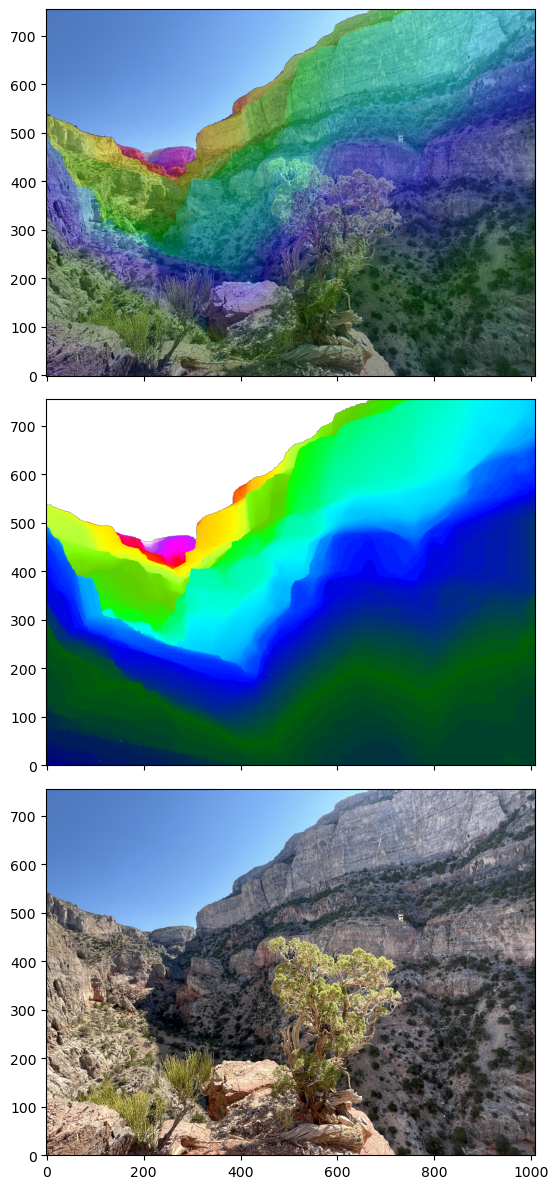

In [ ]:
# overlay ray tracing

if True:
    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True, figsize=(7, 4 * 3))
    r_imgs = {}
    sl = slice(None, None, 4)
    img = imgs[-1]
    axes[0].imshow(img.img[sl,sl], origin='lower')
    axes[2].imshow(img.img[sl,sl], origin='lower')
    r_imgs[img.key] = img.ray_distance(dem, img.get_rays()[...,sl,sl])
    axes[1].imshow(r_imgs[img.key], origin='lower', cmap='gist_ncar')
    axes[0].imshow(r_imgs[img.key], origin='lower', cmap='gist_ncar', alpha=0.4)
    plt.tight_layout()


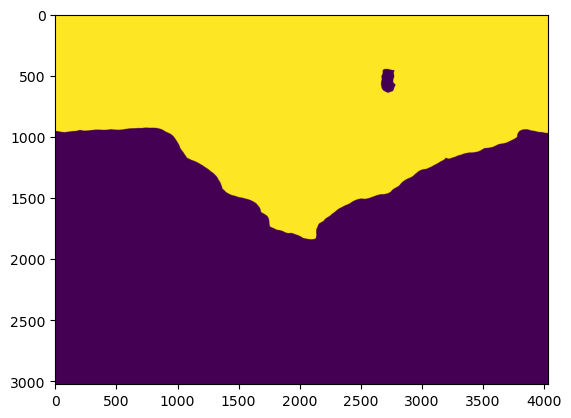

In [12]:
i = imgs[0]
npz = np.load(i.npzfile)
plt.imshow(npz['sky'])


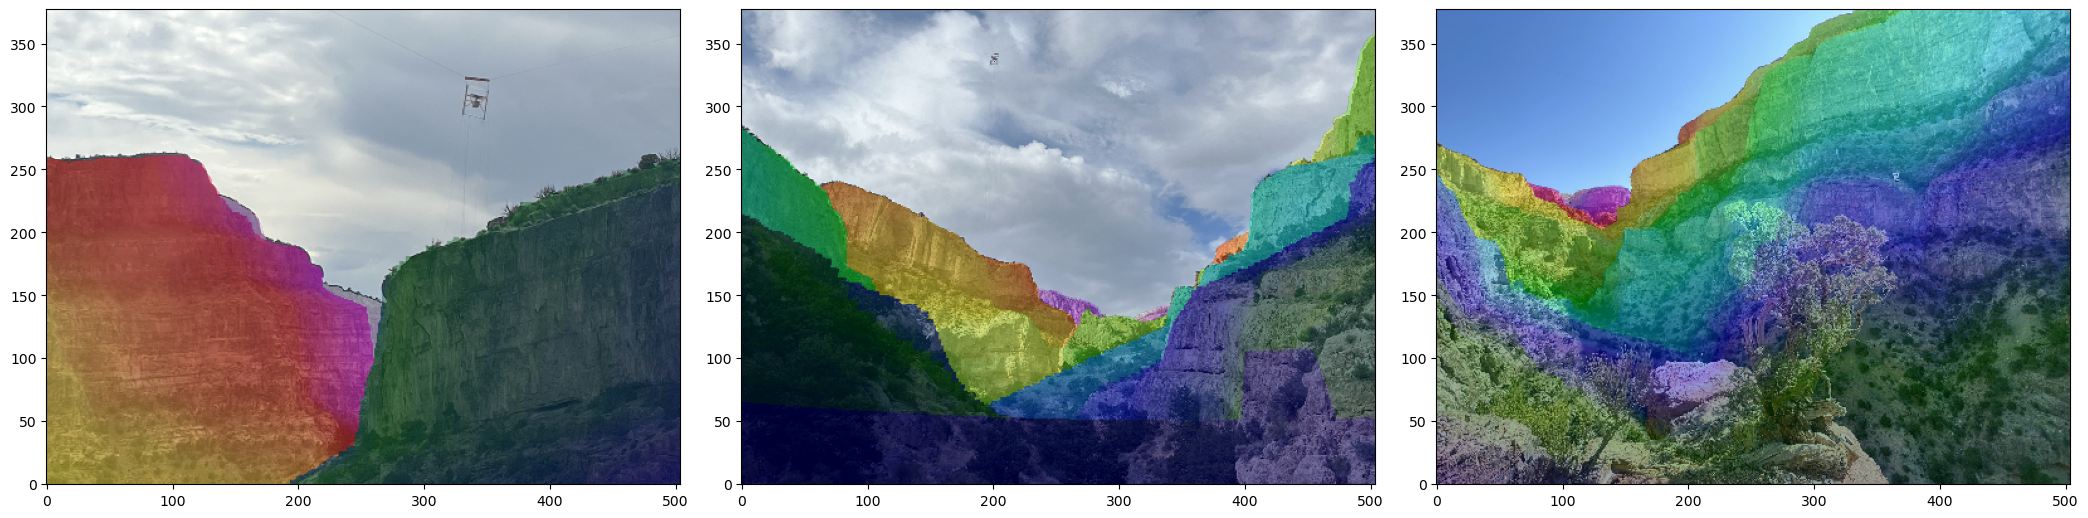

In [13]:
if True:
    fig, axes = plt.subplots(ncols=len(imgs), figsize=(7 * len(imgs), 6))
    if len(imgs) == 1:
        axes = [axes]
    r_imgs = {}
    sl = slice(None, None, 8)
    for cnt, img in enumerate(imgs):
        axes[cnt].imshow(img.img[sl,sl], origin='lower')
        r_imgs[img.key] = img.ray_distance(dem, img.get_rays()[...,sl,sl])
        axes[cnt].imshow(r_imgs[img.key], origin='lower', cmap='gist_ncar', alpha=0.4)
    plt.tight_layout()

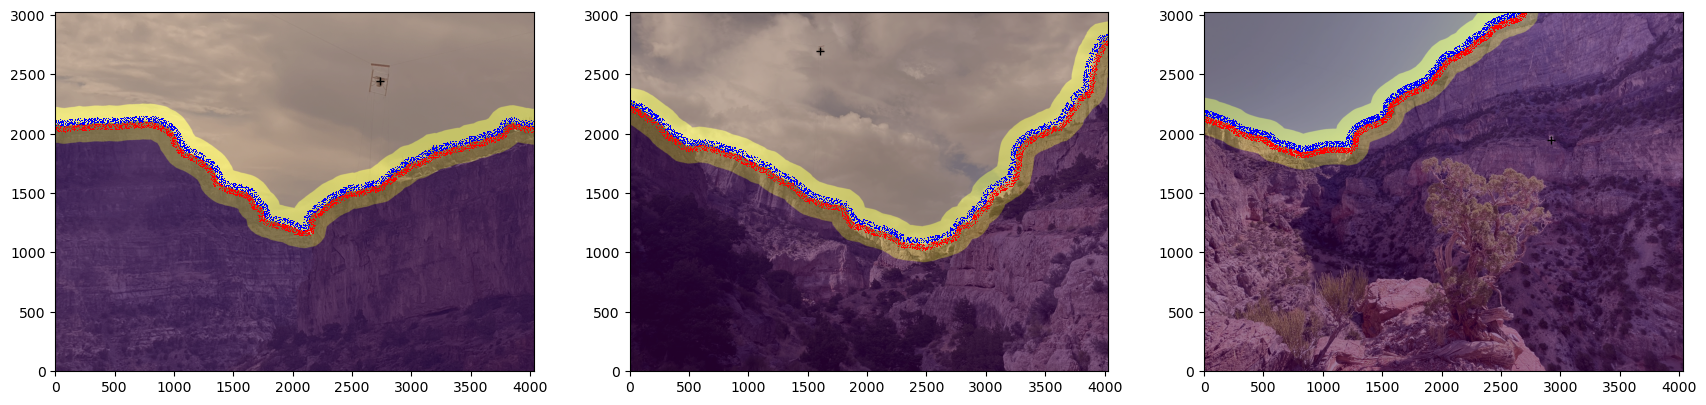

In [18]:
if True:
    fig, axes = plt.subplots(ncols=len(imgs), figsize=(7 * len(imgs), 6))
    if len(imgs) == 1:
        axes = [axes]
    for cnt, img in enumerate(imgs):
        axes[cnt].imshow(img.img, origin='lower')
        axes[cnt].imshow(img.sky_mask, origin='lower', alpha=0.3)
        axes[cnt].imshow(img.horizon_mask, origin='lower', alpha=0.3)
        mask = img.mask_near_horizon(50)
        x, y = img.choose_pixels(mask=mask, N=16000//3)
        is_sky = img.sky_mask[x, y]
        axes[cnt].plot(y[is_sky], x[is_sky], 'b,')
        axes[cnt].plot(y[~is_sky], x[~is_sky], 'r,')
        axes[cnt].plot(*img.meta['ant_px'], 'k+')

In [19]:
#nside = 512
##e0, n0, u0 = (1754, 2100, 1747)
#e0, n0, u0 = start_point = np.array((1767, 2095, 1759), dtype=float)
#rays = et.ray.healpix_rays(nside)
##e0, n0, u0 = start_point = np.array(dem['1P'], dtype=float)
##e0, n0, u0 = (0, 0, 1759)

In [20]:
#healpy.mollview(h.map)
#healpy.mollview(np.log10(ray_trace(start_point)), cmap='plasma')
#healpy.mollview(np.log10(r), cmap='plasma')
#healpy.mollview(np.log10(r2), cmap='plasma')
#healpy.mollview(T[-1], cmap='plasma')
#healpy.mollview((T_sky_full[:, 180]), cmap='plasma')

In [ ]:
I = imgs[2]
I.reset_pixel_choice()
I.horizon_ray_loss(dem, cnt=16000);


'best_prms': ( 1540.51,  1998.55,   1766.85,  1.5421,  0.6131,  0.1584,  2328.30),  #[LOSS= 0.0152]


In [22]:
#TODO: add seed to random things, plumbing for mask and pix width stuff

In [23]:
sigmas = (30.0, 30.0, 30.0, np.deg2rad(5.0), np.deg2rad(5.0), np.deg2rad(5.0), 0.1)

def make_sigmas(imgs):
    return [img.prms[k] * sig if sig == 'f' else sig for k, sig in zip(PRM_ORDER, sigmas) for img in imgs]

def build_model(img, dem, n_rays, eps=0.01):
    """
    eps: per-pixel error rate for mismatches (small)
    """
    @as_op(itypes=[pt.dvector], otypes=[pt.fscalar])
    def horizon_mismatches_loss(theta):
        L = 0.0
        for cnt, img in enumerate(imgs):
            img.set_prms(tuple(theta[cnt*len(PRM_ORDER):(cnt+1)*len(PRM_ORDER)]))
            L += img.horizon_ray_loss(dem, cnt=n_rays)
        return np.array(L / len(imgs), dtype=np.float32)

    with pm.Model() as model:
        prms = []
        sigmas = make_sigmas(imgs)
        for cnt, img in enumerate(imgs):
            _sigmas = sigmas[cnt*len(PRM_ORDER): (cnt+1)*len(PRM_ORDER)]
            prms += [pm.Normal(f"{img.key}_{k}", mu=img.prms[k], sigma=sig) for k, sig in zip(PRM_ORDER, _sigmas)]
        theta = pt.stack(prms)
        L = horizon_mismatches_loss(theta)
        # logp = (N - L)*log(1-eps) + L*log(eps)
        logp = len(imgs) * n_rays * (1 - L) * np.log(1.0 - eps) + len(imgs) * n_rays * L * np.log(eps)
        pm.Potential("lik", logp)

    return model

In [24]:
if True:
    with build_model(I, dem, n_rays=16000, eps=0.01) as model:
        step = pm.DEMetropolisZ(
            S=np.array(make_sigmas(imgs)),
            scaling=0.01,      # much bigger than 1e-3, TODO: may need to tune this
            tune='scaling',   # let it adapt scale
            tune_interval=50, # adapt more often than default 100
        )
        
        trace = pm.sample(
            draws=500,
            tune=100,
            chains=4,
            step=step,
            cores=4,
            random_seed=42,
            progressbar=True,
        )
    arviz.to_netcdf(trace, f"{I.key}_trace.nc");
    print(f"Accepted step fraction = {float(trace.sample_stats.accepted.mean()): 4.3f}")
    # rejecting most steps = steps too big
    # accepting most steps = steps too small

python(39069) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(39070) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



You can find the C code in this temporary file: /var/folders/q0/wmkw3ygx6g39dcd_tv9267z40000gn/T/pytensor_compilation_error_9ft36nsy
library d64 is not found.


CompileError: Compilation failed (return status=1):
/usr/bin/clang++ -dynamiclib -g -Wno-c++11-narrowing -fno-exceptions -fno-unwind-tables -fno-asynchronous-unwind-tables -DNPY_NO_DEPRECATED_API=NPY_1_7_API_VERSION -fPIC -undefined dynamic_lookup -ld64 -I/Users/komalkaur/miniconda3/lib/python3.12/site-packages/numpy/_core/include -I/Users/komalkaur/miniconda3/include/python3.12 -I/Users/komalkaur/miniconda3/lib/python3.12/site-packages/pytensor/link/c/c_code -L/Users/komalkaur/miniconda3/lib -fvisibility=hidden -o /Users/komalkaur/.pytensor/compiledir_macOS-26.0-arm64-arm-64bit-arm-3.12.2-64/lazylinker_ext/lazylinker_ext.so /Users/komalkaur/.pytensor/compiledir_macOS-26.0-arm64-arm-64bit-arm-3.12.2-64/lazylinker_ext/mod.cpp
ld: library not found for -ld64
clang: error: linker command failed with exit code 1 (use -v to see invocation)


In [ ]:
trace_files = sorted(glob.glob("*.nc"))
print(trace_files)
traces = {f.split('_')[0]: arviz.from_netcdf(f) for f in trace_files}

In [ ]:
fig = plt.figure(figsize=(8, 8))
corner.corner(traces['0860'], fig=fig);

In [ ]:
#e,n,u = dem.latlon_to_enu(39.247907, -113.402715)
#u = dem.interp_alt(e, n)
#print(e, n, u)
fig, ax = plt.subplots()
e0, n0, u0 = dem['platform']
rng = 750
terrain_plot(dem, res=dem.res, ax=ax, vmin=u0-300, vmax=u0+200, erng_m=(e0-rng, e0+rng), nrng_m=(n0-rng, n0+rng))
plt.plot([e0], [n0], 's', color='k')
for img in imgs:
    e, n, u = img.prms['e'], img.prms['n'], img.prms['u']
    plt.plot([e], [n], '+', color='k')
    ant_ray = img.get_rays(pixels=np.array(img.meta['ant_px'][::-1]))
    plt.plot([e, e + ant_ray[0] * 220], [n, n + ant_ray[1] * 220], ':', color='k')
    trace = traces[img.key]
    try:
        plt.plot(np.asarray(trace.posterior[f'{img.key}_e']).flatten(), np.asarray(trace.posterior[f'{img.key}_n']).flatten(), '.');
    except(KeyError):
        plt.plot(np.asarray(trace.posterior['e']).flatten(), np.asarray(trace.posterior['n']).flatten(), '.');

based on antenna coords and image params, should be able to read a ray of direction from image enu to antenna. should be able to define enu of antenna and see how close the ray approaches that. minimize angular separation between the two (add this to the loss)